In [319]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [320]:
nav = pd.read_csv("02_nav_history.csv")
aum = pd.read_csv("03_aum_by_fund_house.csv")
sip = pd.read_csv("04_monthly_sip_inflows.csv")
investor = pd.read_csv("08_investor_transactions.csv")
portfolio = pd.read_csv("09_portfolio_holdings.csv")

In [321]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [322]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [323]:
nav.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [324]:
nav.duplicated().sum()

np.int64(0)

In [325]:
nav["date"] = pd.to_datetime(nav["date"])

In [326]:
nav.dtypes

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object

In [327]:
nav.describe()

,amfi_code,date,nav
count,46000.000000,46000,46000.000000
mean,120247.000000,2024-03-16 12:00:00.000000256,269.570265
min,100016.000000,2022-01-03 00:00:00,26.136600
25%,118632.750000,2023-02-08 00:00:00,69.170425
50%,119551.500000,2024-03-16 12:00:00,122.732150
75%,120842.250000,2025-04-23 00:00:00,260.338675
max,149324.000000,2026-05-29 00:00:00,4268.549700
std,14352.317221,NaN,577.187060


In [328]:
nav["amfi_code"].nunique()

40

In [329]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [330]:
aum.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


In [331]:
aum["date"] = pd.to_datetime(aum["date"])

In [332]:
aum.dtypes

date              datetime64[ns]
fund_house                object
aum_lakh_crore           float64
aum_crore                  int64
num_schemes                int64
dtype: object

In [333]:
aum.isnull().sum()

date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

In [334]:
aum.duplicated().sum()

np.int64(0)

In [335]:
aum.describe()

,date,aum_lakh_crore,aum_crore,num_schemes
count,90,90.000000,9.000000e+01,90.000000
mean,2024-02-19 10:40:00,4.352889,4.352889e+05,152.200000
min,2022-03-31 00:00:00,1.050000,1.050000e+05,56.000000
25%,2023-03-31 00:00:00,2.525000,2.525000e+05,95.000000
50%,2024-03-31 00:00:00,3.450000,3.450000e+05,172.500000
75%,2024-12-31 00:00:00,5.675000,5.675000e+05,195.000000
max,2025-12-31 00:00:00,12.500000,1.250000e+06,216.000000
std,NaN,2.734328,2.734328e+05,52.108832


In [336]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [337]:
sip.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     object 
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.4+ KB


In [338]:
sip.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

In [339]:
sip["yoy_growth_pct"] = sip["yoy_growth_pct"].fillna(0)

In [340]:
sip.isnull().sum()

month                        0
sip_inflow_crore             0
active_sip_accounts_crore    0
new_sip_accounts_lakh        0
sip_aum_lakh_crore           0
yoy_growth_pct               0
dtype: int64

In [341]:
sip.duplicated().sum()

np.int64(0)

In [342]:
sip.describe()

,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,19577.520833,7.189583,9.893750,8.632083,23.592708
std,6354.329621,1.271457,5.370745,3.613579,17.106061
min,11438.000000,4.910000,7.500000,4.800000,0.000000
25%,13658.500000,6.110000,8.775000,5.790000,11.850000
50%,18224.000000,7.150000,9.200000,7.265000,23.980000
75%,25944.250000,8.300000,9.562500,10.525000,36.500000
max,31002.000000,9.350000,46.000000,15.900000,53.050000


In [343]:
investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [344]:
investor.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [345]:
investor.isnull().sum()



investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [346]:
investor.duplicated().sum()


np.int64(0)

In [347]:
investor.describe()

,amfi_code,amount_inr,annual_income_lakh
count,32778.000000,32778.000000,32778.000000
mean,120264.617518,107437.318628,26.181219
std,14370.205345,150415.905084,20.805425
min,100016.000000,400.000000,3.000000
25%,118632.000000,3153.000000,10.600000
50%,119551.000000,17782.500000,19.700000
75%,120843.000000,189324.250000,37.400000
max,149324.000000,597498.000000,99.700000


In [348]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [349]:
portfolio.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [350]:
portfolio.isnull().sum()


amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [351]:
portfolio.duplicated().sum()


np.int64(0)

In [352]:
portfolio.describe()

,amfi_code,weight_pct,market_value_cr,current_price_inr
count,322.000000,322.000000,322.000000,322.000000
mean,121210.434783,10.558975,1008.846646,4080.870528
std,14669.377920,6.060137,543.827535,2265.186353
min,100016.000000,0.990000,55.740000,246.780000
25%,118633.000000,6.015000,513.702500,2081.985000
50%,119552.000000,9.395000,1045.670000,4138.995000
75%,120842.750000,13.917500,1477.502500,5914.307500
max,149324.000000,38.180000,1999.500000,7942.960000


In [353]:
# NAV Trend Analysis
fig = px.line(nav,x="date",y="nav",color="amfi_code",title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)")

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    template="plotly_white"
)
plt.savefig("../reports/nav_trend.png", dpi=300, bbox_inches="tight")
fig.show()

<Figure size 640x480 with 0 Axes>

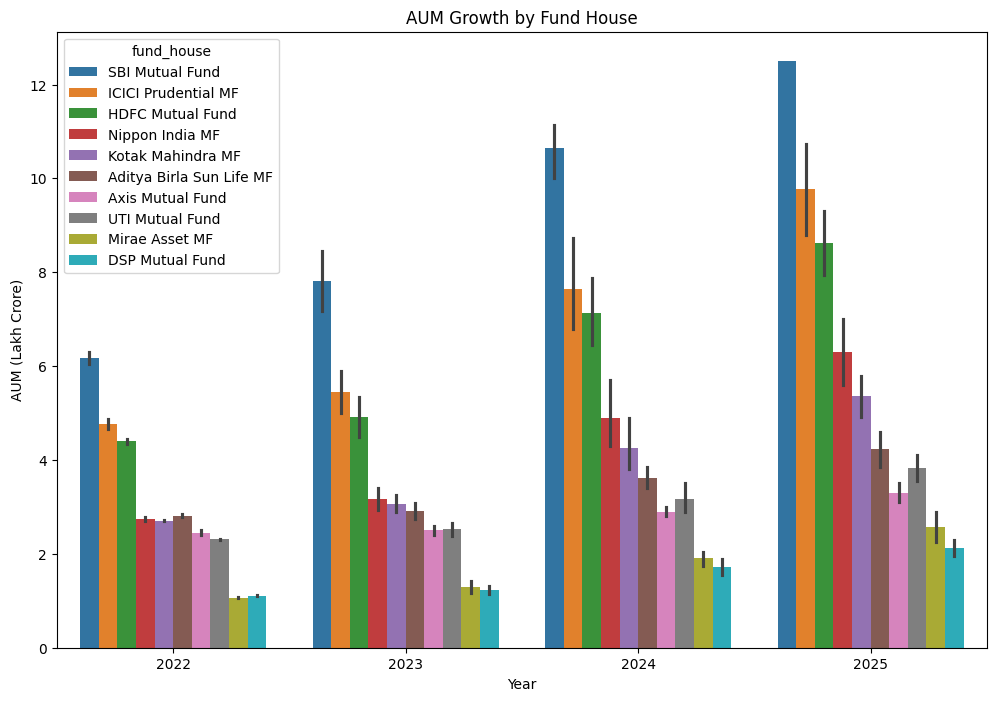

In [354]:
# AUM Growth Bar chart

# Extract year
aum["year"] = aum["date"].dt.year
plt.figure(figsize=(12,8)) #size of the chart
sns.barplot(x='year',y='aum_lakh_crore',data=aum,hue='fund_house')
plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.savefig("../reports/aum_growth.png", dpi=300, bbox_inches="tight") #Export Charts as PNG
plt.show()

In [355]:
sip.dtypes

month                         object
sip_inflow_crore               int64
active_sip_accounts_crore    float64
new_sip_accounts_lakh        float64
sip_aum_lakh_crore           float64
yoy_growth_pct               float64
dtype: object

In [356]:
# SIP Inflow Time-Series (Jan 2022 – Dec 2025)

# converting month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(sip,x="month",y="sip_inflow_crore",title="Monthly SIP Inflow (Jan 2022 - Dec 2025)",markers=True)
fig.update_layout(xaxis_title="Month",yaxis_title="SIP Inflow (Crore ₹)")
fig.add_annotation(x="2025-12-01",y=31002,text="₹31,002 Cr (Dec 2025)",bgcolor="yellow")
fig.write_image("../reports/sip_trend.png") #Export Charts as PNG
fig.show()

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [ ]:
# Category-wise inflow heatmap
category = pd.read_csv("05_category_inflows.csv")

In [ ]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413
1,2024-04,Mid Cap,3897
2,2024-04,Small Cap,3533
3,2024-04,Flexi Cap,4947
4,2024-04,Large & Mid Cap,4214


In [ ]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             144 non-null    object
 1   category          144 non-null    object
 2   net_inflow_crore  144 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 3.5+ KB


In [ ]:
category["month"] = pd.to_datetime(category["month"])

In [ ]:
category["month"] = category["month"].dt.strftime("%b-%Y")

In [ ]:
category.isna().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [ ]:
category.duplicated().sum()

np.int64(0)

In [ ]:
category.describe()

,net_inflow_crore
count,144.000000
mean,6473.881944
std,9718.335947
min,437.000000
25%,1801.250000
50%,4148.000000
75%,5304.000000
max,41952.000000


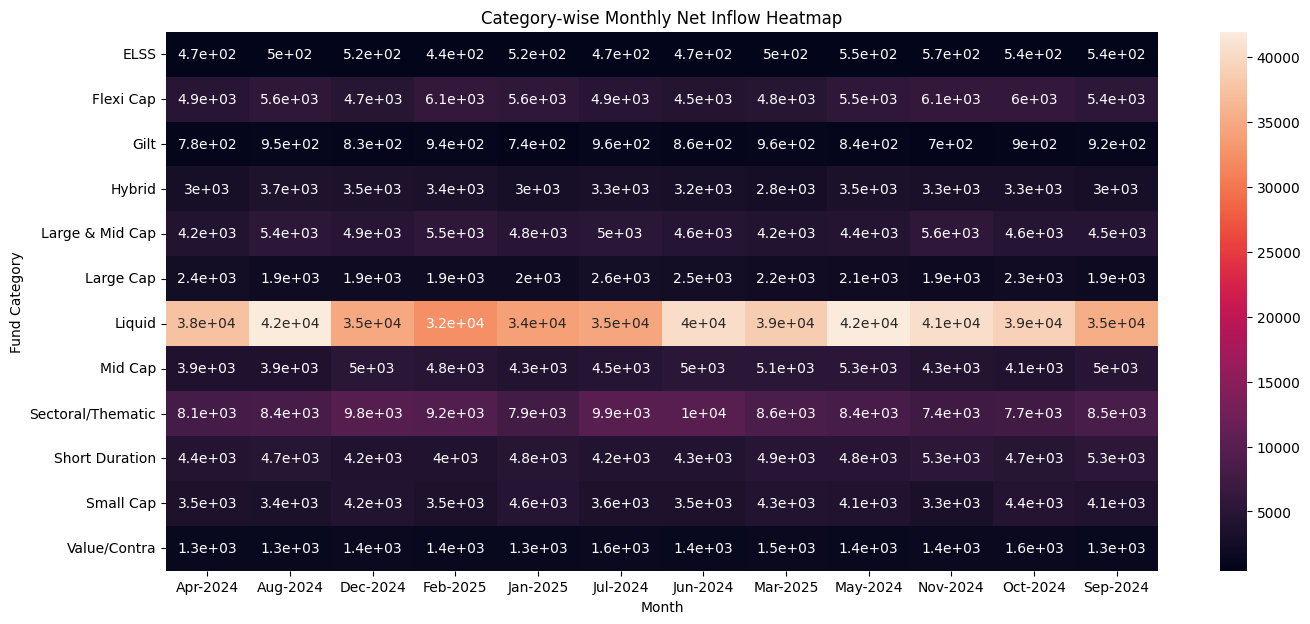

In [ ]:
heatmap_data = category.pivot_table(index="category",columns="month",values="net_inflow_crore",aggfunc="sum")
plt.figure(figsize=(16,7))
sns.heatmap(heatmap_data,annot=True)
plt.title("Category-wise Monthly Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.savefig("../reports/Category-wise_inflow.png", dpi=300, bbox_inches="tight") #Export Charts as PNG
plt.show()


In [ ]:
# Investor demographics:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

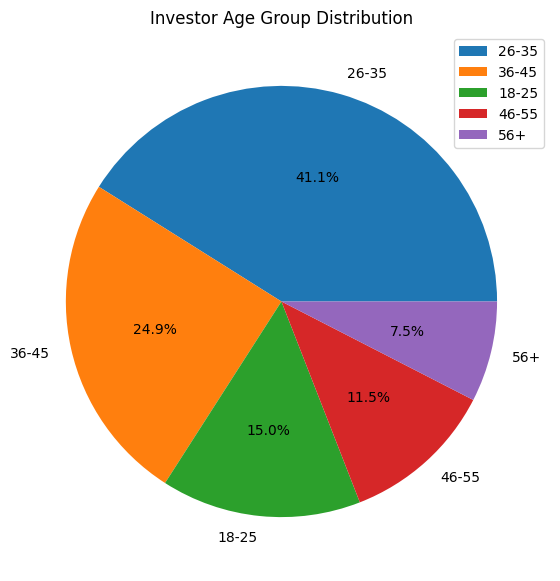

In [ ]:
# Age Group Distribution (Pie Chart)
age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(age_counts,labels=age_counts.index,autopct="%1.1f%%")
plt.legend(loc='upper right')
plt.title("Investor Age Group Distribution")
plt.savefig("../reports/investor_Age_Group_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

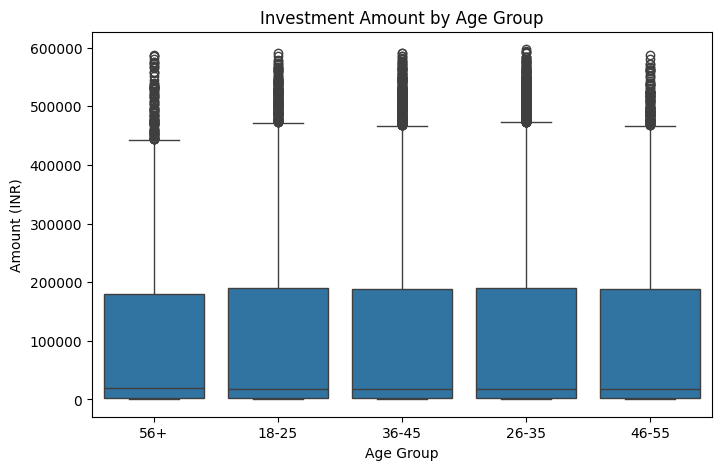

In [ ]:
# SIP Amount Box Plot by Age Group
plt.figure(figsize=(8,5))
sns.boxplot(data=investor,x="age_group",y="amount_inr")
plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.savefig("../reports/Investment_Amount_by_AgeGroup.png", dpi=300, bbox_inches="tight")
plt.show()

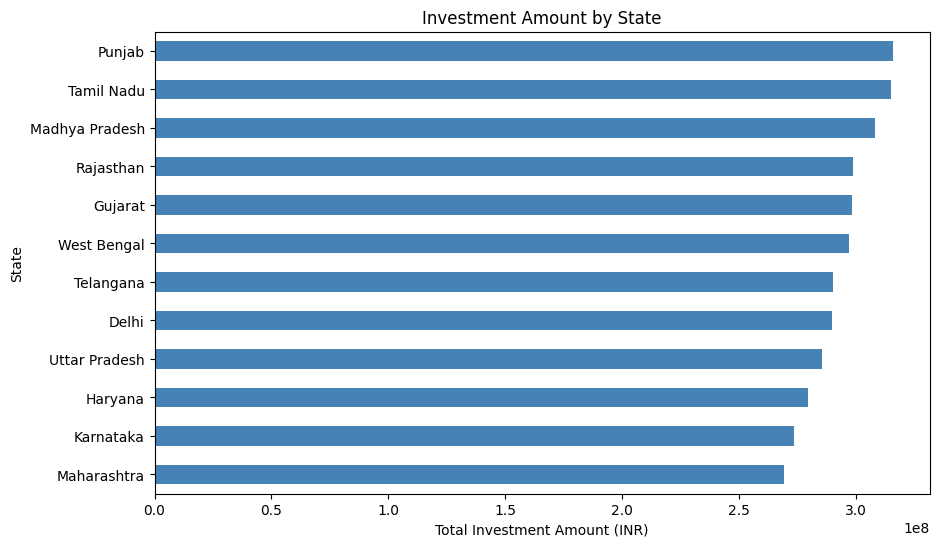

In [ ]:
# Horizontal Bar Chart – Investment Amount by State

state_amount = investor.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,6))
state_amount.plot(kind="barh", color="steelblue")
plt.title("Investment Amount by State")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")
plt.savefig("../reports/Investment_Amount_by_State.png", dpi=300, bbox_inches="tight")
plt.show()

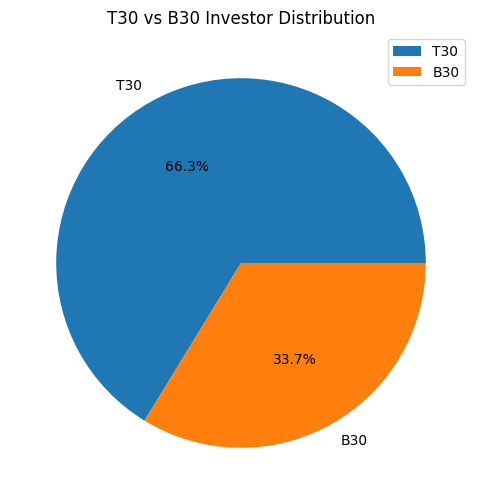

In [ ]:
# T30 vs B30 Pie Chart
tier = investor["city_tier"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(tier,labels=tier.index,autopct="%1.1f%%")
plt.title("T30 vs B30 Investor Distribution")
plt.legend(loc="upper right")
plt.savefig("../reports/T30_vs_B30_Pie_Chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
folio = pd.read_csv("06_industry_folio_count.csv")

In [ ]:
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [ ]:
folio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     object 
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.1+ KB


In [ ]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

In [ ]:
folio["month"] = pd.to_datetime(folio["month"])

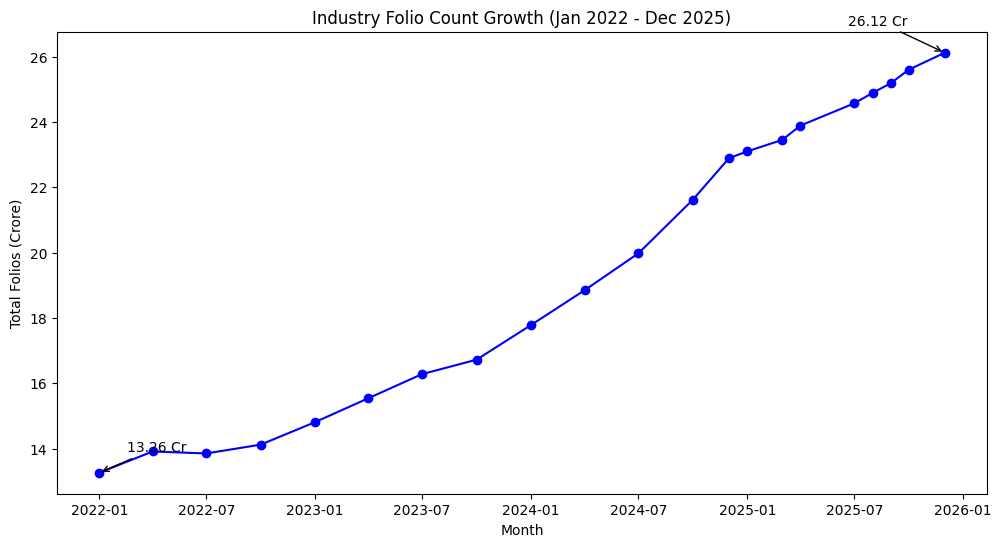

In [ ]:
# Folio count growth: 
# Line chart Jan 2022 to Dec 2025
plt.figure(figsize=(12,6))
plt.plot(folio["month"],folio["total_folios_crore"],marker="o",color="blue")
# Starting milestone
plt.annotate("13.26 Cr",xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),xytext=(20,15),textcoords="offset points",
    arrowprops=dict(arrowstyle="->"))
# Ending milestone
plt.annotate("26.12 Cr",xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),xytext=(-70,20),textcoords="offset points",
    arrowprops=dict(arrowstyle="->"))
plt.title("Industry Folio Count Growth (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.savefig("../reports/Folio_count_growth.png", dpi=300, bbox_inches="tight")
plt.show()

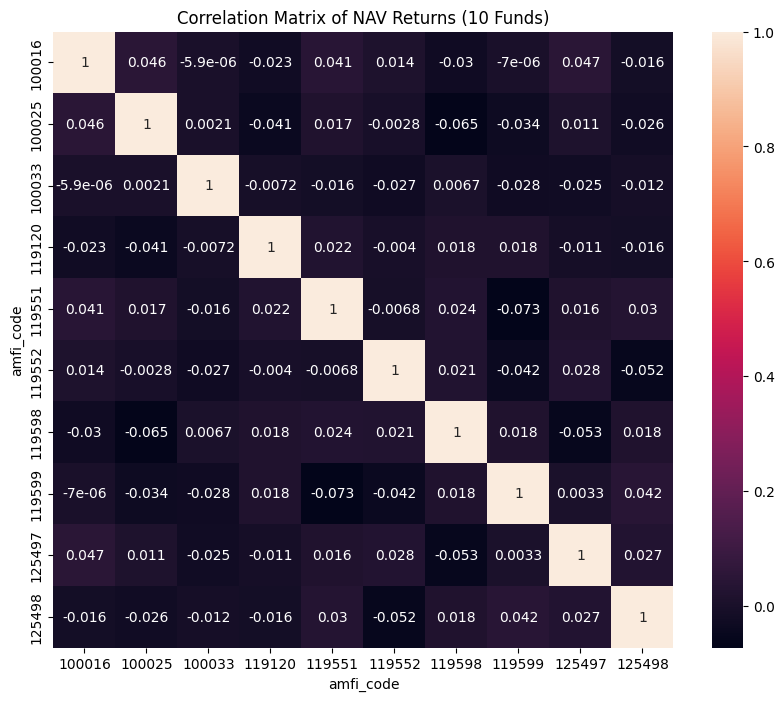

In [ ]:
# Correlation Matrix of NAV Returns (10 Funds)
top10 = nav["amfi_code"].unique()[:10] #selecting 10 funds
nav10 = nav[nav["amfi_code"].isin(top10)]#filtering thoe funds
pivot = nav10.pivot(index="date",columns="amfi_code",values="nav") #create a pivot table
# Calculate Daily NAV Returns
returns = pivot.pct_change()  # pct_change() calculates the daily percentage return of each fund.
corr = returns.corr() #Correlation Matrix

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.title("Correlation Matrix of NAV Returns (10 Funds)")
plt.savefig("../reports/Correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# 9- Top holdings sector distribution

portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [ ]:
sector_weight = portfolio.groupby("sector")["weight_pct"].sum()

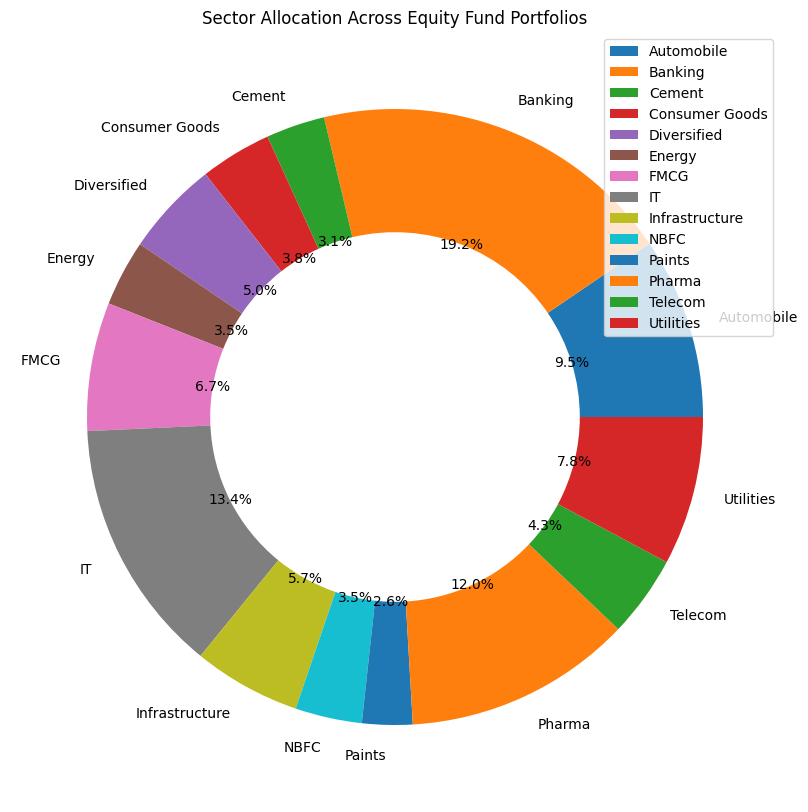

In [ ]:
# Donut Chart
plt.figure(figsize=(10,10))
plt.pie(sector_weight,labels=sector_weight.index,autopct="%1.1f%%",wedgeprops=dict(width=0.4)) # width=0.4  create donut chart)
plt.title("Sector Allocation Across Equity Fund Portfolios")
plt.legend(loc="upper right")
plt.savefig("../reports/Top_holdings_sector_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Summarise 10 key EDA findings as
# bullet points in notebook markdown
# cells